# Playground: Clasificación de cancelaciones hoteleras con XGBoost
---

- **Notebook:** *playground* (exploración libre, autónomo)
- **Dataset:** reservas hoteleras (`is_canceled`)
- **Última actualización:** 27/05/2026

### Objetivo
Recorrer el **ciclo completo** de un modelo de clasificación siguiendo el mismo estilo y proceso que los notebooks de clase (`recursos/`): exploración de datos, preprocesado, entrenamiento de un **XGBoost**, evaluación y ajuste de hiperparámetros.

### Temas a tratar
1. Lectura y exploración de datos (EDA)
2. Fuga de información (*data leakage*) y limpieza
3. Preprocesado: imputación y codificación *one-hot*
4. Modelo **XGBoost** baseline
5. Evaluación (métricas, matriz de confusión, curva ROC, importancia de variables)
6. Optimización de hiperparámetros con `GridSearchCV`

> ⚠️ Este notebook es **autónomo**: **no** importa nada de `src/`. Todo el código vive aquí, igual que en los notebooks de `recursos/`.

### Información útil
+ [Documentación oficial XGBoost](https://xgboost.readthedocs.io/)
+ [Documentación oficial scikit-learn — métricas](https://scikit-learn.org/stable/modules/model_evaluation.html)
+ [Documentación oficial Plotly](https://plotly.com/python/)

## 0. Configuración del Notebook
Importaremos todas las librerías y funciones que vemos relevantes para el notebook que vamos a crear. Lo ideal sería tener todas las importaciones juntas, de tal manera que se puedan controlar de manera sencilla.

### Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
)
from xgboost import XGBClassifier

### Definición de constantes

In [2]:
PATH_DIRECTORIO_DATOS = "../../data/raw"

In [3]:
PATH_DATASET_HOTEL = f"{PATH_DIRECTORIO_DATOS}/dataset_practica_final.csv"

In [4]:
# Columna objetivo y nombres legibles de las clases
target_column = 'is_canceled'
list_nombres_clases = ['No cancelada', 'Cancelada']
dict_target_hotel = {0: 'No cancelada', 1: 'Cancelada'}

### Definición de funciones

In [5]:
def plot_matriz_correlacion(df: pd.DataFrame, variable_dependiente: str):
    """Genera una matriz de correlación interactiva utilizando Plotly.

    Crea una visualización de mapa de calor que muestra las correlaciones entre todas
    las variables numéricas del DataFrame, con anotaciones de los valores exactos.
    Adicionalmente, imprime un ranking de correlaciones con la variable dependiente
    especificada.

    Args:
        df (pd.DataFrame): DataFrame que contiene las variables numéricas para analizar.
        variable_dependiente (str): Nombre de la columna que se considera la variable dependiente,
                                   cuyas correlaciones se mostrarán ordenadas.

    Returns:
        None: Muestra el gráfico interactivo con Plotly y una tabla de correlaciones
              con la variable dependiente en la consola.

    Example:
        >>> plot_matriz_correlacion(df_hotel, "is_canceled")
    """

    # Crear matriz de correlación para visualizar relaciones entre variables con Plotly
    correlation_matrix = df.corr()

    # Crear un mapa de calor interactivo con Plotly
    fig = px.imshow(
        correlation_matrix,
        text_auto='.2f',                    # Mostrar valores numéricos con 2 decimales
        color_continuous_scale='RdBu_r',    # Esquema de colores (rojo-blanco-azul invertido)
        zmin=-1, zmax=1,                    # Rango de valores
        aspect="auto",                      # Ajustar aspecto automáticamente
        title='Matriz de Correlación entre Variables'
    )

    # Mejorar el diseño
    fig.update_layout(
        width=800,
        height=700,
        coloraxis_colorbar=dict(
            title="Coeficiente<br>de Correlación",
            thicknessmode="pixels", thickness=20,
            lenmode="pixels", len=500,
            yanchor="top", y=1,
            ticks="outside"
        ),
        font=dict(size=12),
    )

    # Identificar y mostrar las correlaciones más fuertes con la variable dependiente
    correlaciones_con_dependiente = correlation_matrix[variable_dependiente].sort_values(ascending=False)

    # Mostrar el gráfico interactivo
    fig.show(renderer='iframe')

    # Imprimir correlaciones con la variable dependiente
    print(f"\nCorrelaciones con '{variable_dependiente}':")
    print(correlaciones_con_dependiente)

## 1. Lectura de datos
Leemos el dataset directamente del directorio de datos crudos. `pandas` interpreta automáticamente la cadena `NULL` del CSV como valor ausente (`NaN`).

In [6]:
df_hotel = pd.read_csv(PATH_DATASET_HOTEL)

In [7]:
# Mostramos las primeras filas del DataFrame
df_hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [8]:
# Mostramos las dimensiones del DataFrame
df_hotel.shape

(119390, 32)

## 2. Comprobación y preprocesamiento de datos
Veremos cuáles son los datos que tenemos en el DataFrame, si los tipos asignados tienen sentido, descriptivo estadístico de las columnas, etc.

In [9]:
# Mostramos información del DataFrame
df_hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [10]:
# Descripción estadística de las columnas numéricas
df_hotel.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [11]:
# También se pueden ver los estadísticos de las columnas categóricas
df_hotel.describe(include='object').transpose()

/tmp/ipykernel_191736/2655485526.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_hotel.describe(include='object').transpose()


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


### La variable objetivo: `is_canceled`

In [12]:
# Obtenemos las frecuencias absolutas de la columna target
df_hotel[target_column].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [13]:
# Y añadiendo el parámetro `normalize=True` obtenemos las frecuencias relativas
df_hotel[target_column].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

In [14]:
# Lo mismo, pero con nombres legibles de las clases
df_hotel[target_column].map(dict_target_hotel).value_counts(normalize=True)

is_canceled
No cancelada    0.629584
Cancelada       0.370416
Name: proportion, dtype: float64

**Observación.** Alrededor del **37 % de las reservas se cancelan**. Es un problema de **clasificación binaria desbalanceado**: tendremos que usar una partición *estratificada* y mirar métricas más allá del *accuracy* (precisión, recall, AUC).

### Valores ausentes (huecos en los datos)

In [15]:
# Número de valores ausentes por columna (solo las que tienen)
missing = df_hotel.isna().sum()
missing[missing > 0].sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

In [16]:
# Porcentaje de valores ausentes por columna
porcentaje_missing = (df_hotel.isna().mean() * 100).round(2)
porcentaje_missing[porcentaje_missing > 0].sort_values(ascending=False)

company    94.31
agent      13.69
country     0.41
dtype: float64

**Decisiones.** `company` está vacía en ~94 % → la eliminaremos. `agent` (~14 % de huecos) es un **identificador numérico pero categórico** (la media de un ID no tiene sentido) → lo trataremos como texto. `country` y `children` tienen pocos huecos → imputación sencilla.

### Fuga de información (*data leakage*) — ¡muy importante!
Antes de modelar hay que detectar columnas que **revelan la respuesta** o que no existirían en el momento de predecir. Comprobamos `reservation_status`:

In [17]:
# ¿Cómo se relaciona reservation_status con is_canceled?
pd.crosstab(df_hotel['reservation_status'], df_hotel['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


**Confirmado.** `reservation_status = 'Canceled' / 'No-Show'` coincide **exactamente** con `is_canceled = 1`, y `'Check-Out'` con `0`. Junto con `reservation_status_date` (la *fecha* de ese desenlace), describen lo que pasó **después** de decidir la cancelación. **Si las dejáramos, el modelo "vería la respuesta"** y obtendría ~100 % de acierto, engañoso e inútil. → **Las eliminamos siempre.**

### Variables categóricas y tasa de cancelación
Una forma muy informativa de explorar categóricas frente a la clase es la **tasa de cancelación** (media de `is_canceled`) por categoría.

In [18]:
# Frecuencias de deposit_type
df_hotel['deposit_type'].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [19]:
# Tasa de cancelación por tipo de depósito
df_hotel.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)

deposit_type
Non Refund    0.993624
No Deposit    0.283770
Refundable    0.222222
Name: is_canceled, dtype: float64

In [20]:
# Tasa de cancelación por tipo de hotel y por tipo de cliente
print(df_hotel.groupby('hotel')['is_canceled'].mean())
print()
print(df_hotel.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False))

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64

customer_type
Transient          0.407463
Contract           0.309617
Transient-Party    0.254299
Group              0.102253
Name: is_canceled, dtype: float64


**Hallazgo clave.** `deposit_type = 'Non Refund'` (depósito **no** reembolsable) cancela **~99 %** de las veces. Parece un contrasentido, pero es un *proxy*: ese tipo de reserva lo concentran bloqueos especulativos de agencias/turoperadores y *no-shows*. Es la variable más predictiva del dataset.

### ¿Aporta `arrival_date_year`?
El dataset tiene cuatro variables de fecha de llegada (`year`, `month`, `week_number`, `day_of_month`). Comprobamos si el **año** aporta algo:

In [21]:
# Tamaño y tasa de cancelación por año
df_hotel.groupby('arrival_date_year')['is_canceled'].agg(['size', 'mean']).round(4)

,size,mean
arrival_date_year,,
2015,21996,0.3702
2016,56707,0.3586
2017,40687,0.3870


In [22]:
# ¿Qué meses cubre cada año?
meses = ['January', 'February', 'March', 'April', 'May', 'June',
         'July', 'August', 'September', 'October', 'November', 'December']
for anio, sub in df_hotel.groupby('arrival_date_year'):
    presentes = sorted(set(sub['arrival_date_month']), key=meses.index)
    print(f'{anio}: {len(presentes):2d} meses -> {presentes}')

2015:  6 meses -> ['July', 'August', 'September', 'October', 'November', 'December']
2016: 12 meses -> ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
2017:  8 meses -> ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']


**Decisión: descartamos `arrival_date_year`.** La tasa de cancelación es casi plana entre años (≈ 37 % / 36 % / 39 %), los años son **parciales** (2015 solo jul–dic, 2017 solo ene–ago) y, sobre todo, **no generaliza**: el modelo debe puntuar reservas *futuras* y un año no visto (2018+) no tiene valor interpretable. La estacionalidad ya la recogen `month` y `week_number`, que sí se repiten cada año.

### Preprocesamiento: limpieza y preparación
Aplicamos las decisiones anteriores para construir `df_hotel_preprocessed`.

In [23]:
# Eliminamos las columnas problemáticas
# - Fuga de información: 'reservation_status' y 'reservation_status_date'
# - 'company': ausente en ~94 % de las filas
# - 'arrival_date_year': no generaliza (años parciales)
list_columnas_a_eliminar = [
    'reservation_status',
    'reservation_status_date',
    'company',
    'arrival_date_year',
]
df_hotel_preprocessed = df_hotel.drop(columns=list_columnas_a_eliminar)
df_hotel_preprocessed.shape

(119390, 28)

In [24]:
# Eliminamos las reservas sin ningún huésped (registros erróneos)
mask_sin_huespedes = df_hotel_preprocessed[['adults', 'children', 'babies']].fillna(0).sum(axis=1) == 0
print(f'Reservas sin huéspedes a eliminar: {mask_sin_huespedes.sum()}')
df_hotel_preprocessed = df_hotel_preprocessed[~mask_sin_huespedes].reset_index(drop=True)
df_hotel_preprocessed.shape

Reservas sin huéspedes a eliminar: 180


(119210, 28)

In [25]:
# Tratamiento de valores ausentes y de la columna 'agent'
# - 'children': pocos nulos -> imputamos con la mediana
# - 'country': nulos -> 'Unknown' (una categoría más)
# - 'agent': ID numérico pero CATEGÓRICO; nulos -> '0' (sentinela 'sin agencia') y a texto
df_hotel_preprocessed['children'] = df_hotel_preprocessed['children'].fillna(df_hotel_preprocessed['children'].median())
df_hotel_preprocessed['country'] = df_hotel_preprocessed['country'].fillna('Unknown')
df_hotel_preprocessed['agent'] = df_hotel_preprocessed['agent'].fillna(0).astype(int).astype(str)

In [26]:
# Volvemos a mostrar la información del DataFrame ya limpio
df_hotel_preprocessed.info()

<class 'pandas.DataFrame'>
RangeIndex: 119210 entries, 0 to 119209
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119210 non-null  str    
 1   is_canceled                     119210 non-null  int64  
 2   lead_time                       119210 non-null  int64  
 3   arrival_date_month              119210 non-null  str    
 4   arrival_date_week_number        119210 non-null  int64  
 5   arrival_date_day_of_month       119210 non-null  int64  
 6   stays_in_weekend_nights         119210 non-null  int64  
 7   stays_in_week_nights            119210 non-null  int64  
 8   adults                          119210 non-null  int64  
 9   children                        119210 non-null  float64
 10  babies                          119210 non-null  int64  
 11  meal                            119210 non-null  str    
 12  country                    

In [27]:
# Confirmamos que ya no quedan valores ausentes
df_hotel_preprocessed.isna().sum().sum()

np.int64(0)

### Relaciones entre variables: *pairplot*
Enfrentamos algunas numéricas entre sí coloreando por la clase. Como el dataset es grande (>100 000 filas), tomamos una **muestra** de 2 000 reservas para que el gráfico sea legible y rápido.

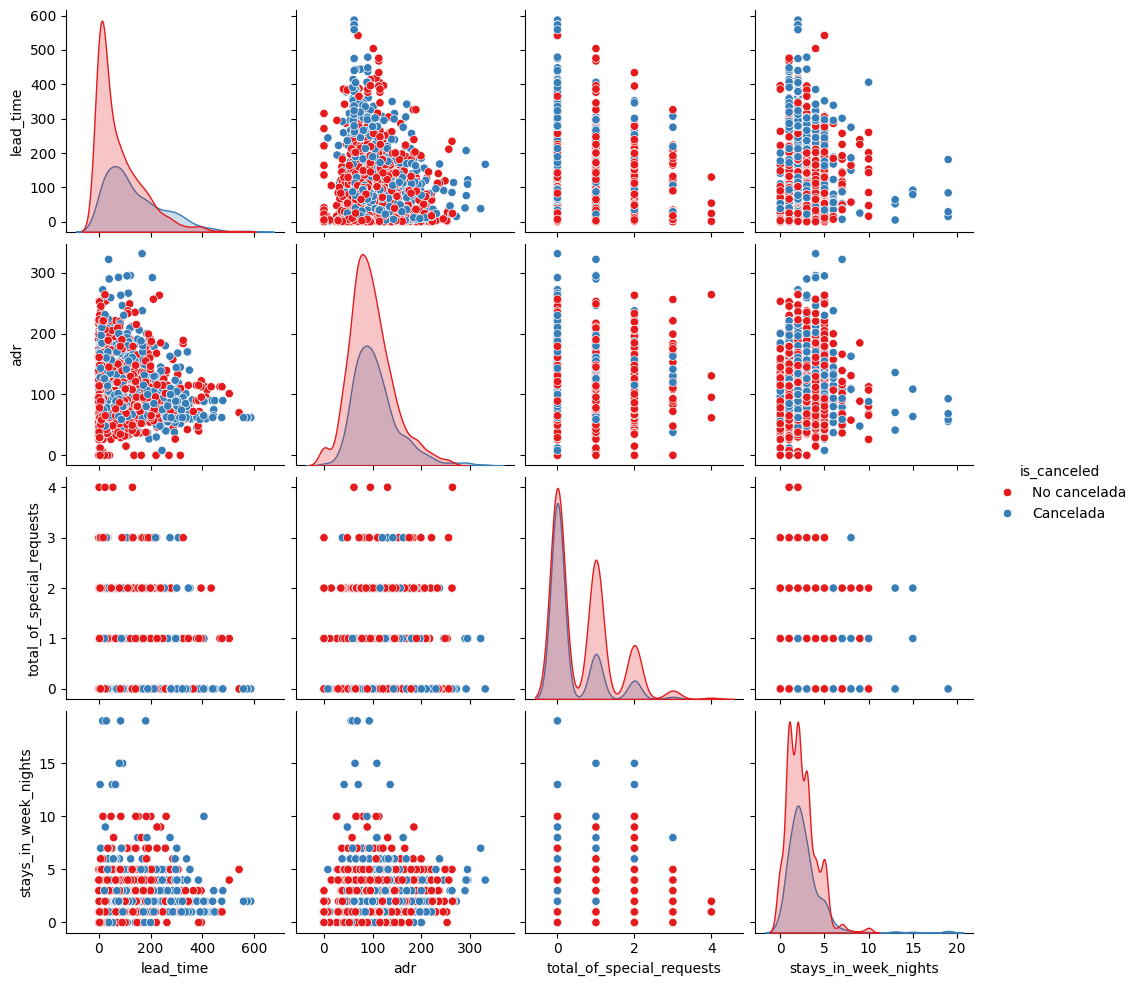

In [28]:
# Pairplot sobre una muestra, coloreando por la clase
list_columnas_pairplot = ['lead_time', 'adr', 'total_of_special_requests', 'stays_in_week_nights']
df_muestra = df_hotel_preprocessed.sample(2000, random_state=42).copy()
df_muestra[target_column] = df_muestra[target_column].map(dict_target_hotel)
sns.pairplot(df_muestra[list_columnas_pairplot + [target_column]], hue=target_column, palette='Set1')

**Lectura.** Las nubes de ambas clases se solapan mucho en las variables continuas: ninguna pareja separa por sí sola las cancelaciones. La señal fuerte está en las **categóricas** (`deposit_type`, `country`, `market_segment`...) y en `lead_time`.

### Matriz de correlación
Usamos la función `plot_matriz_correlacion` sobre las variables **numéricas** para ver si hay redundancias y cómo se relacionan con `is_canceled`.

In [29]:
# Matriz de correlación entre las variables numéricas
df_numericas = df_hotel_preprocessed.select_dtypes(include=np.number)
plot_matriz_correlacion(df_numericas, target_column)


Correlaciones con 'is_canceled':
is_canceled                       1.000000
lead_time                         0.292876
previous_cancellations            0.110139
adults                            0.058182
days_in_waiting_list              0.054301
adr                               0.046492
stays_in_week_nights              0.025542
arrival_date_week_number          0.008315
children                          0.004851
stays_in_weekend_nights          -0.001323
arrival_date_day_of_month        -0.005948
babies                           -0.032569
previous_bookings_not_canceled   -0.057365
is_repeated_guest                -0.083745
booking_changes                  -0.144832
required_car_parking_spaces      -0.195701
total_of_special_requests        -0.234877
Name: is_canceled, dtype: float64


**Lectura.** No hay parejas fuertemente redundantes (ningún |coef| ≈ 0.9). `lead_time` es la numérica que más correlaciona con la cancelación (positiva: más antelación → más cancela); `total_of_special_requests` y `required_car_parking_spaces`, al revés.

## 3. Preparación de los datos para el modelo
Separamos variables independientes (`X`) de la objetivo (`y`) y codificamos las categóricas.

In [30]:
# Seleccionamos las columnas independientes
list_columnas_independientes = df_hotel_preprocessed.drop(columns=target_column).columns.to_list()
list_columnas_independientes

['hotel',
 'lead_time',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [31]:
# Preparación de los datos para el modelo de clasificación
X_hotel = df_hotel_preprocessed[list_columnas_independientes]
y_hotel = df_hotel_preprocessed[target_column]

In [32]:
X_hotel.head()

,hotel,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,342,July,27,1,0,0,2,0.0,0,...,C,C,3,No Deposit,0,0,Transient,0.0,0,0
1,Resort Hotel,737,July,27,1,0,0,2,0.0,0,...,C,C,4,No Deposit,0,0,Transient,0.0,0,0
2,Resort Hotel,7,July,27,1,0,1,1,0.0,0,...,A,C,0,No Deposit,0,0,Transient,75.0,0,0
3,Resort Hotel,13,July,27,1,0,1,1,0.0,0,...,A,A,0,No Deposit,304,0,Transient,75.0,0,0
4,Resort Hotel,14,July,27,1,0,2,2,0.0,0,...,A,A,0,No Deposit,240,0,Transient,98.0,0,1


### Codificación *one-hot* (`get_dummies`)
XGBoost necesita variables numéricas: convertimos las categóricas en columnas *dummy* (0/1), igual que en clase.

In [33]:
# Convertimos las variables categóricas a variables dummy (one-hot encoding)
X_hotel_encoded = pd.get_dummies(X_hotel)

In [34]:
# La codificación dispara el número de columnas (alta cardinalidad de country/agent)
print('Antes de codificar :', X_hotel.shape)
print('Después de codificar:', X_hotel_encoded.shape)

Antes de codificar : (119210, 27)
Después de codificar: (119210, 587)


In [35]:
# Mostramos las primeras filas del DataFrame codificado
X_hotel_encoded.head()

,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,...,agent_93,agent_94,agent_95,agent_96,agent_98,agent_99,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,27,1,0,0,2,0.0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,737,27,1,0,0,2,0.0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,7,27,1,0,1,1,0.0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
3,13,27,1,0,1,1,0.0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,14,27,1,0,2,2,0.0,0,0,0,...,False,False,False,False,False,False,False,False,True,False


> **Nota didáctica.** `country` (~178 países) y `agent` (~330 agencias) generan **cientos** de columnas. XGBoost lo tolera bien, pero en un pipeline de producción convendría **limitar la cardinalidad** (agrupar categorías poco frecuentes) para controlar la dimensionalidad.

### Train-test split (estratificado)
Mantenemos la proporción de clases (~37 %) en ambos conjuntos con `stratify`.

In [36]:
# Hacemos un train-test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_hotel_encoded, y_hotel, test_size=0.2, random_state=42, stratify=y_hotel
)

In [37]:
# Verificamos el ratio de las clases en el conjunto de entrenamiento
print("Distribución de clases en el conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))

Distribución de clases en el conjunto de entrenamiento:
is_canceled
0    0.629236
1    0.370764
Name: proportion, dtype: float64


In [38]:
# Verificamos el ratio de las clases en el conjunto de prueba
print("Distribución de clases en el conjunto de prueba:")
print(y_test.value_counts(normalize=True))

Distribución de clases en el conjunto de prueba:
is_canceled
0    0.629226
1    0.370774
Name: proportion, dtype: float64


## 4. XGBoost — modelo baseline
XGBoost (*eXtreme Gradient Boosting*) combina muchos árboles de forma **secuencial**, donde cada árbol corrige el error del anterior (*boosting*). Entrenamos un modelo base con hiperparámetros sensatos.

In [39]:
# Entrenamiento de un modelo de XGBoost Classifier
modelo_xgbc = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, eval_metric='logloss', random_state=42)
modelo_xgbc.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [40]:
# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_xgbc.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_xgbc.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.86
Precisión: 0.85
Recall:    0.76
F1-Score:  0.80
AUC:       0.94



In [41]:
# Reporte de clasificación detallado
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89     15002
           1       0.85      0.76      0.80      8840

    accuracy                           0.86     23842
   macro avg       0.86      0.84      0.85     23842
weighted avg       0.86      0.86      0.86     23842



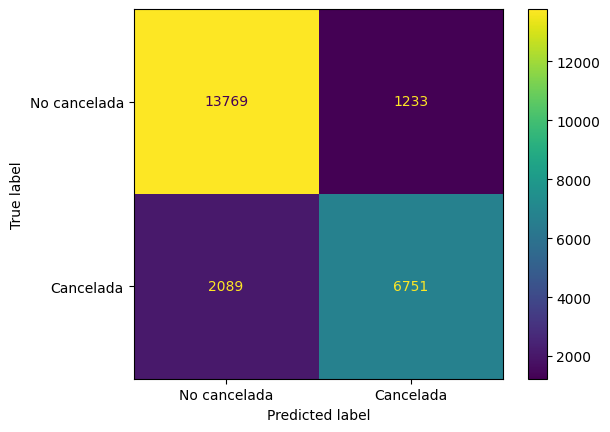

In [42]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot()
plt.show()

### Curva ROC
La curva ROC enfrenta la tasa de verdaderos positivos (TPR) frente a la de falsos positivos (FPR) según el umbral; el AUC resume su calidad (0.5 = azar, 1 = perfecto).

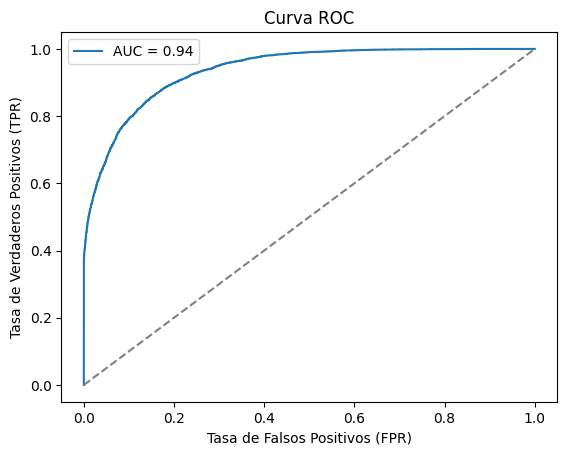

In [43]:
# Curva ROC (matplotlib)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [44]:
# Versión de Plotly de la curva ROC
fig = px.area(
    x=fpr,
    y=tpr,
    title=f'ROC Curve (AUC={auc:.4f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=700, height=500
)
fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')
fig.show(renderer='iframe')

## 5. Importancia de variables
XGBoost expone `feature_importances_`: cuánto se apoya el modelo en cada columna. Mostramos las **20 más importantes**.

In [45]:
# Importancia de variables
col_importancia_xgb = modelo_xgbc.feature_importances_

df_importances_xgb = pd.DataFrame({
    'variable': X_hotel_encoded.columns,
    'importancia': col_importancia_xgb
})

# Nos quedamos con las 20 variables más importantes
df_importances_xgb = df_importances_xgb.sort_values(by='importancia', ascending=False).head(20)
df_importances_xgb = df_importances_xgb.sort_values(by='importancia', ascending=True)
df_importances_xgb

,variable,importancia
306,agent_17,0.006848
235,assigned_room_type_A,0.007697
239,assigned_room_type_E,0.007751
218,market_segment_Offline TA/TO,0.008493
554,agent_7,0.008891
586,customer_type_Transient-Party,0.008927
583,customer_type_Contract,0.009475
10,previous_bookings_not_canceled,0.010739
585,customer_type_Transient,0.013806
0,lead_time,0.014083


In [46]:
# Visualización de la importancia de las variables
fig = px.bar(
    df_importances_xgb,
    x='importancia',
    y='variable',
    text='importancia',
    text_auto=".2%",
    title='Importancia de las variables en el modelo XGBoost (Top 20)',
    labels={'x': 'Importancia', 'y': 'Variable'},
    width=800, height=600
)
fig.update_layout(xaxis_tickangle=-45)
fig.show(renderer='iframe')

**Lectura.** Las columnas *dummy* de `deposit_type_Non Refund`, junto a `lead_time`, `country_*` y `market_segment_*`, dominan la predicción — coherente con el EDA.

## 6. Optimización de hiperparámetros con `GridSearchCV`
Buscamos automáticamente la mejor combinación de hiperparámetros por **validación cruzada**, optimizando el **AUC** (la métrica más adecuada para este problema desbalanceado).

#### Modelo con optimización de hiperparámetros
Usamos `GridSearchCV` para encontrar los hiperparámetros que maximizan el AUC.

In [56]:
# Entrenamos un modelo de XGBoost usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'n_estimators': [500, 600],
    'max_depth': [14],
    'learning_rate':  [0.1],
}

modelo_xgbc = XGBClassifier(eval_metric='logloss', random_state=42)
modelo_xgbc_cv = GridSearchCV(modelo_xgbc, dict_parametros, cv=3, scoring='roc_auc')
modelo_xgbc_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1], 'max_depth': [14], 'n_estimators': [500, 600]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [57]:
# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_xgbc_cv.best_params_}")
print(f"Mejor score obtenido (AUC en CV): {modelo_xgbc_cv.best_score_:.4f}")

Mejores hiperparámetros encontrados: {'learning_rate': 0.1, 'max_depth': 14, 'n_estimators': 500}
Mejor score obtenido (AUC en CV): 0.9573


In [58]:
# Entrenamos el modelo con los mejores hiperparámetros encontrados
modelo_xgbc = XGBClassifier(**modelo_xgbc_cv.best_params_, eval_metric='logloss', random_state=42)
modelo_xgbc.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_xgbc.predict(X_test)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
y_proba = modelo_xgbc.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  0.89
Precisión: 0.87
Recall:    0.84
F1-Score:  0.85
AUC:       0.96



## 7. Conclusiones
- El **EDA** revela un problema **desbalanceado** (~37 % cancela) y una columna de **fuga** (`reservation_status*`) que hay que eliminar sí o sí.
- La señal predictiva vive sobre todo en **categóricas** (`deposit_type = Non Refund` ≈ 99 % de cancelación) y en `lead_time`.
- **XGBoost** sobre los datos codificados con *one-hot* alcanza un **AUC ≈ 0.95**, y el ajuste de hiperparámetros con `GridSearchCV` lo mejora ligeramente.